In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/train.csv")
df.head()

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,Churn
0,20,11.055215,221.104302,Premium,Mailed check,No,Both,No,Mobile,36.758104,63.531377,10,Sci-Fi,2.176498,4,Male,3,No,No,0
1,57,5.175208,294.986882,Basic,Credit card,Yes,Movies,No,Tablet,32.450568,25.725595,18,Action,3.478632,8,Male,23,No,Yes,0
2,73,12.106657,883.785952,Basic,Mailed check,Yes,Movies,No,Computer,7.395160,57.364061,23,Fantasy,4.238824,6,Male,1,Yes,Yes,0
3,32,7.263743,232.439774,Basic,Electronic check,No,TV Shows,No,Tablet,27.960389,131.537507,30,Drama,4.276013,2,Male,24,Yes,Yes,0
4,57,16.953078,966.325422,Premium,Electronic check,Yes,TV Shows,No,TV,20.083397,45.356653,20,Comedy,3.616170,4,Female,0,No,No,0


# Feature vs Target Visualizations

In [3]:
# Let's look at the relationship between AccountAge and Churn

In [4]:
account_age_dist = (
    df.groupby("AccountAge")
      .agg(
          churn_rate=("Churn", "mean"),
          customer_count=("Churn", "size")
      )
      .reset_index()
)

In [5]:
account_age_dist

,AccountAge,churn_rate,customer_count
0,1,0.328536,2015
1,2,0.321991,1969
2,3,0.322404,2013
3,4,0.340237,2028
4,5,0.323335,1967
...,...,...,...
114,115,0.074864,2017
115,116,0.078004,2064
116,117,0.081801,2066
117,118,0.072211,2008


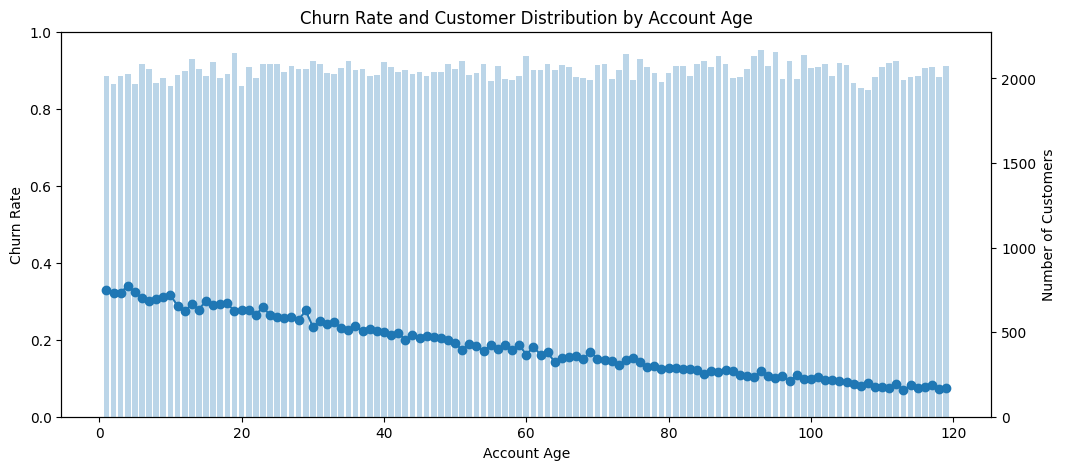

In [6]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    account_age_dist["AccountAge"],
    account_age_dist["churn_rate"],
    marker="o"
)

ax1.set_xlabel("Account Age")
ax1.set_ylabel("Churn Rate")
ax1.set_ylim(0,1)

ax2 = ax1.twinx()

ax2.bar(
    account_age_dist["AccountAge"],
    account_age_dist["customer_count"],
    alpha=0.3
)

ax2.set_ylabel("Number of Customers")

plt.title("Churn Rate and Customer Distribution by Account Age")

plt.show()

In [7]:
# As the account age grows, churn rate is doing down.

---

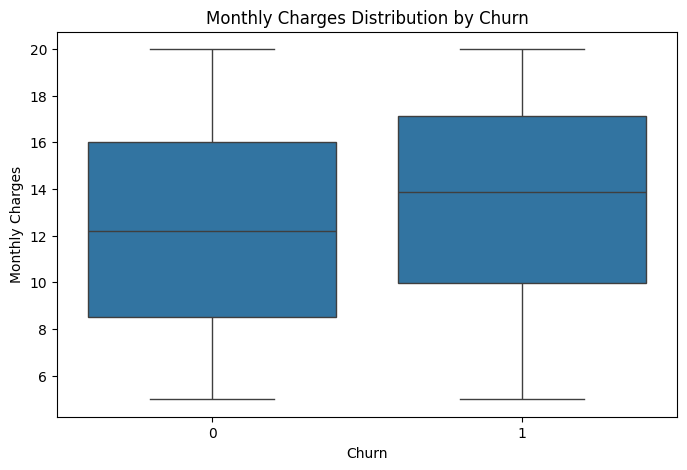

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

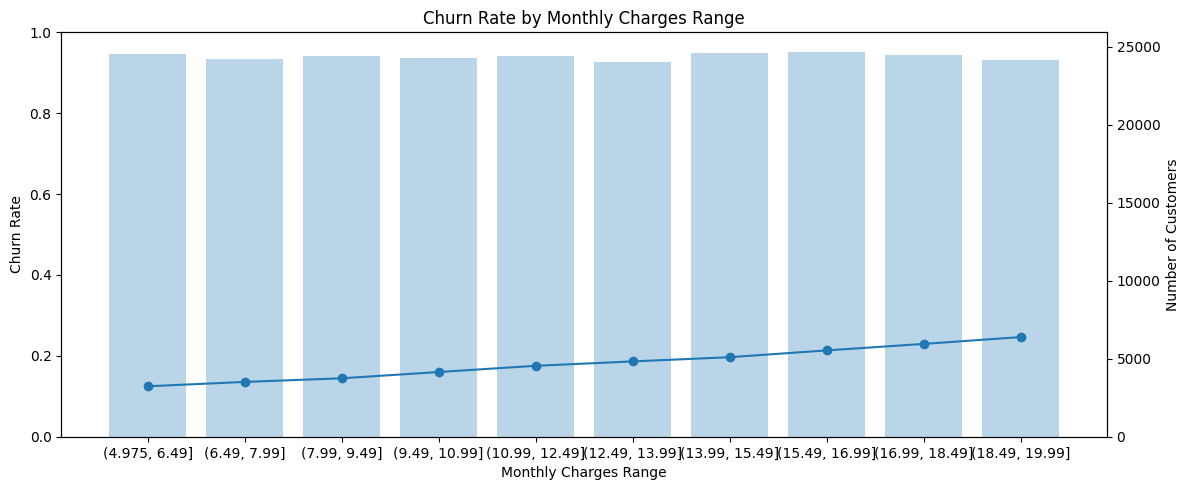

In [12]:
import matplotlib.pyplot as plt

monthly_charges_dist = (
    df.assign(
        MonthlyChargesGroup=pd.cut(
            df["MonthlyCharges"],
            bins=10
        )
    )
    .groupby("MonthlyChargesGroup", observed=True)
    .agg(
        churn_rate=("Churn", "mean"),
        customer_count=("Churn", "size")
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    monthly_charges_dist["MonthlyChargesGroup"].astype(str),
    monthly_charges_dist["churn_rate"],
    marker="o"
)

ax1.set_xlabel("Monthly Charges Range")
ax1.set_ylabel("Churn Rate")
ax1.set_ylim(0,1)

ax2 = ax1.twinx()

ax2.bar(
    monthly_charges_dist["MonthlyChargesGroup"].astype(str),
    monthly_charges_dist["customer_count"],
    alpha=0.3
)

ax2.set_ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.title("Churn Rate by Monthly Charges Range")
plt.tight_layout()

plt.show()

In [ ]:
# Customers who churn have a higher median monthly charge compared to customers who stay, suggesting that higher monthly costs may increase churn probability

In [ ]:
df.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "std"]
)

,mean,median,std
Churn,,,
0,12.286129,12.189954,4.317675
1,13.414880,13.855745,4.251322


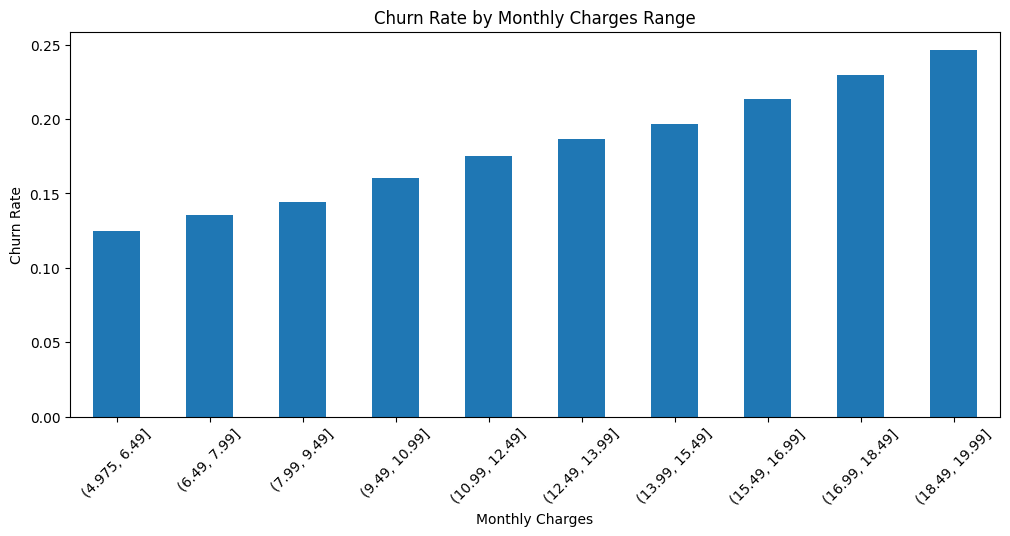

In [ ]:
df["MonthlyChargesGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=10
)

monthly_churn = (
    df.groupby("MonthlyChargesGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("Monthly Charges")
plt.title("Churn Rate by Monthly Charges Range")

plt.xticks(rotation=45)
plt.show()

In [ ]:
df[["MonthlyCharges", "Churn"]].corr()

,MonthlyCharges,Churn
MonthlyCharges,1.000000,0.100473
Churn,0.100473,1.000000


---

In [ ]:
subscription_churn = (
    df.groupby("SubscriptionType")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

subscription_churn

SubscriptionType
Basic       0.196521
Standard    0.184314
Premium     0.162775
Name: Churn, dtype: float64

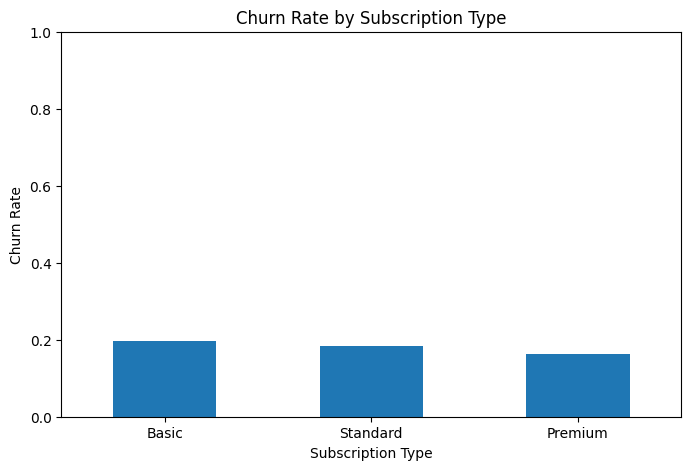

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

subscription_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("Subscription Type")
plt.title("Churn Rate by Subscription Type")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()

---

In [ ]:
payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

payment_churn

PaymentMethod
Electronic check    0.192471
Mailed check        0.190888
Bank transfer       0.179269
Credit card         0.162251
Name: Churn, dtype: float64

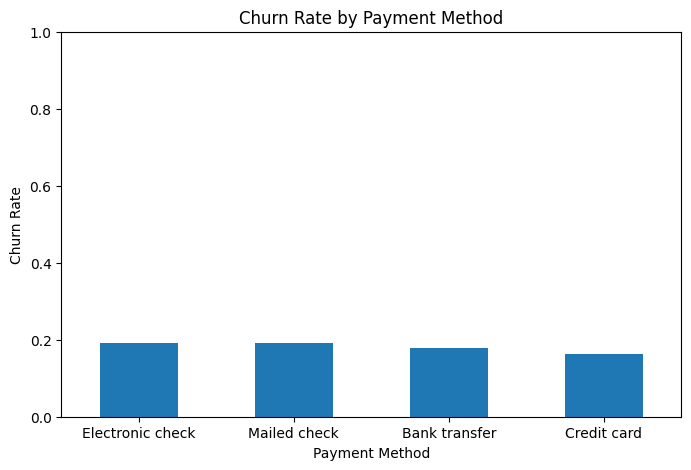

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

payment_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("Payment Method")
plt.title("Churn Rate by Payment Method")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()

---

PaperlessBilling
No     0.181587
Yes    0.180876
Name: Churn, dtype: float64


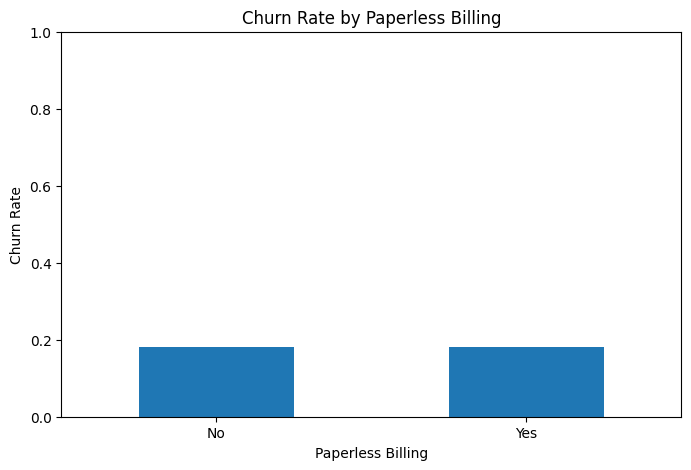

In [ ]:
paperless_churn = (
    df.groupby("PaperlessBilling")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(paperless_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

paperless_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("Paperless Billing")
plt.title("Churn Rate by Paperless Billing")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()

---

ContentType
Both        0.188470
Movies      0.177764
TV Shows    0.177398
Name: Churn, dtype: float64


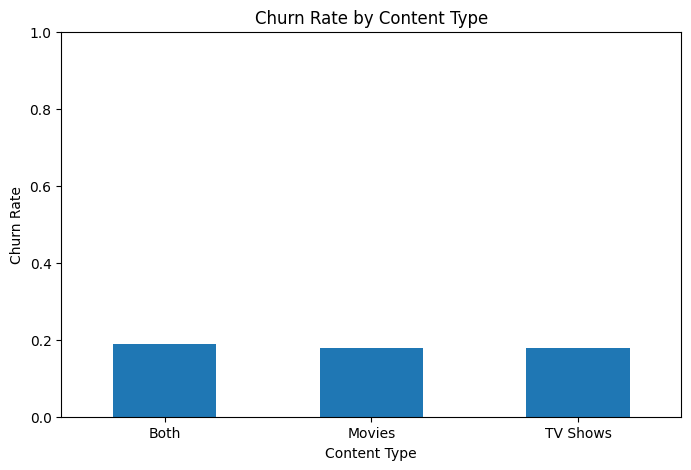

In [ ]:
contenttype_churn = (
    df.groupby("ContentType")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(contenttype_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

contenttype_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("Content Type")
plt.title("Churn Rate by Content Type")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()

---

MultiDeviceAccess
No     0.181727
Yes    0.180736
Name: Churn, dtype: float64


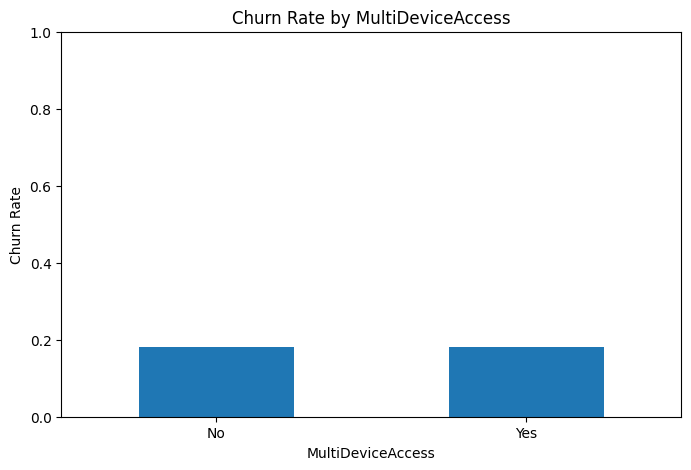

In [ ]:
multidevice_churn = (
    df.groupby("MultiDeviceAccess")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(multidevice_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

multidevice_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("MultiDeviceAccess")
plt.title("Churn Rate by MultiDeviceAccess")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()



---

DeviceRegistered
Mobile      0.182372
Tablet      0.182147
Computer    0.181350
TV          0.179044
Name: Churn, dtype: float64


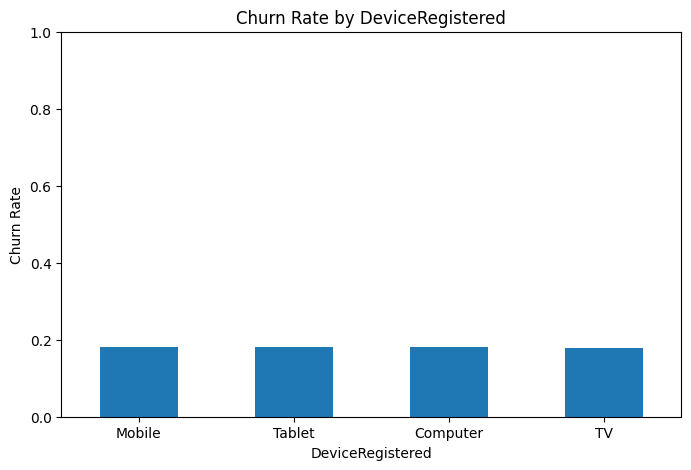

In [ ]:
deviceregistered_churn = (
    df.groupby("DeviceRegistered")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(deviceregistered_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

deviceregistered_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("DeviceRegistered")
plt.title("Churn Rate by DeviceRegistered")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()



---

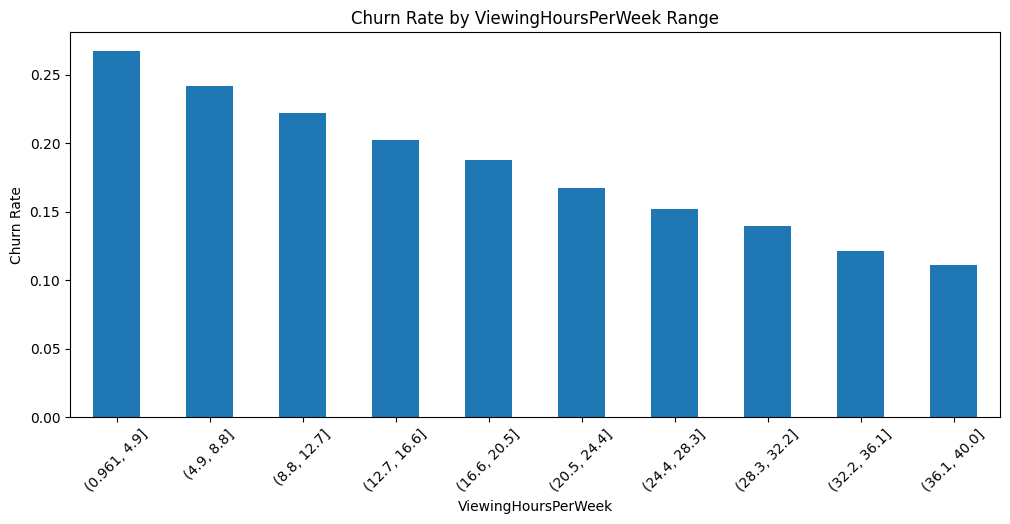

In [ ]:
df["ViewingHoursPerWeekGroup"] = pd.cut(
    df["ViewingHoursPerWeek"],
    bins=10
)

monthly_churn = (
    df.groupby("ViewingHoursPerWeekGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("ViewingHoursPerWeek")
plt.title("Churn Rate by ViewingHoursPerWeek Range")

plt.xticks(rotation=45)
plt.show()

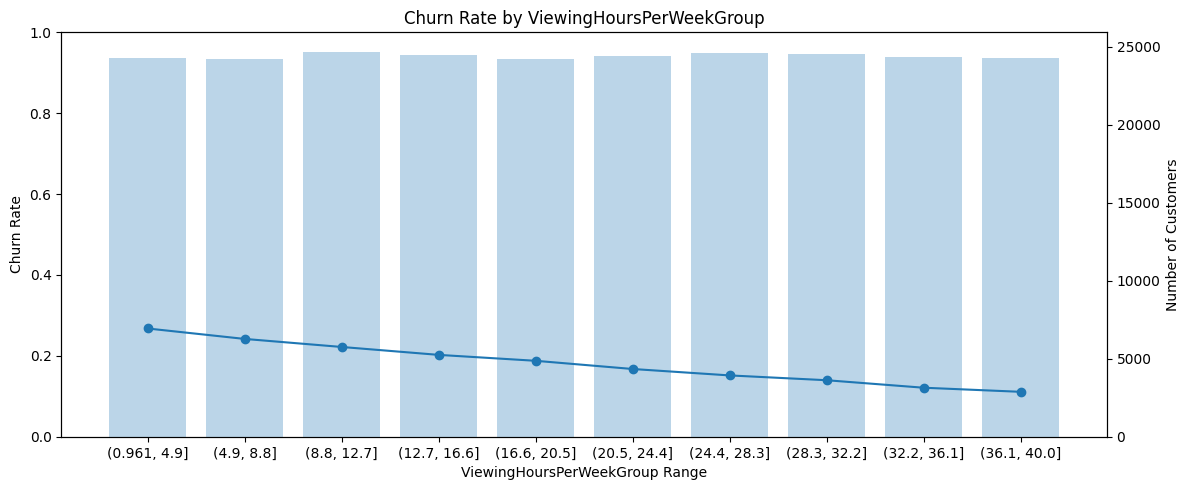

In [13]:
import matplotlib.pyplot as plt

view_hours_per_week_dist = (
    df.assign(
        ViewingHoursPerWeekGroup=pd.cut(
            df["ViewingHoursPerWeek"],
            bins=10
        )
    )
    .groupby("ViewingHoursPerWeekGroup", observed=True)
    .agg(
        churn_rate=("Churn", "mean"),
        customer_count=("Churn", "size")
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    view_hours_per_week_dist["ViewingHoursPerWeekGroup"].astype(str),
    view_hours_per_week_dist["churn_rate"],
    marker="o"
)

ax1.set_xlabel("ViewingHoursPerWeekGroup Range")
ax1.set_ylabel("Churn Rate")
ax1.set_ylim(0,1)

ax2 = ax1.twinx()

ax2.bar(
    view_hours_per_week_dist["ViewingHoursPerWeekGroup"].astype(str),
    view_hours_per_week_dist["customer_count"],
    alpha=0.3
)

ax2.set_ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.title("Churn Rate by ViewingHoursPerWeekGroup")
plt.tight_layout()

plt.show()

In [ ]:
df[["ViewingHoursPerWeek", "Churn"]].corr()

,ViewingHoursPerWeek,Churn
ViewingHoursPerWeek,1.000000,-0.128645
Churn,-0.128645,1.000000


---

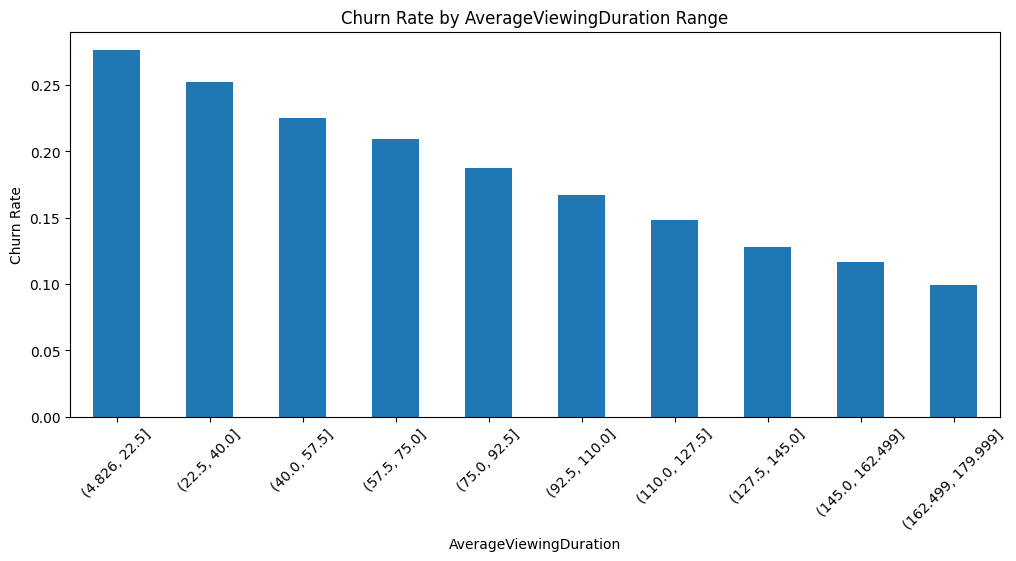

In [ ]:
df["AverageViewingDurationGroup"] = pd.cut(
    df["AverageViewingDuration"],
    bins=10
)

monthly_churn = (
    df.groupby("AverageViewingDurationGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("AverageViewingDuration")
plt.title("Churn Rate by AverageViewingDuration Range")

plt.xticks(rotation=45)
plt.show()

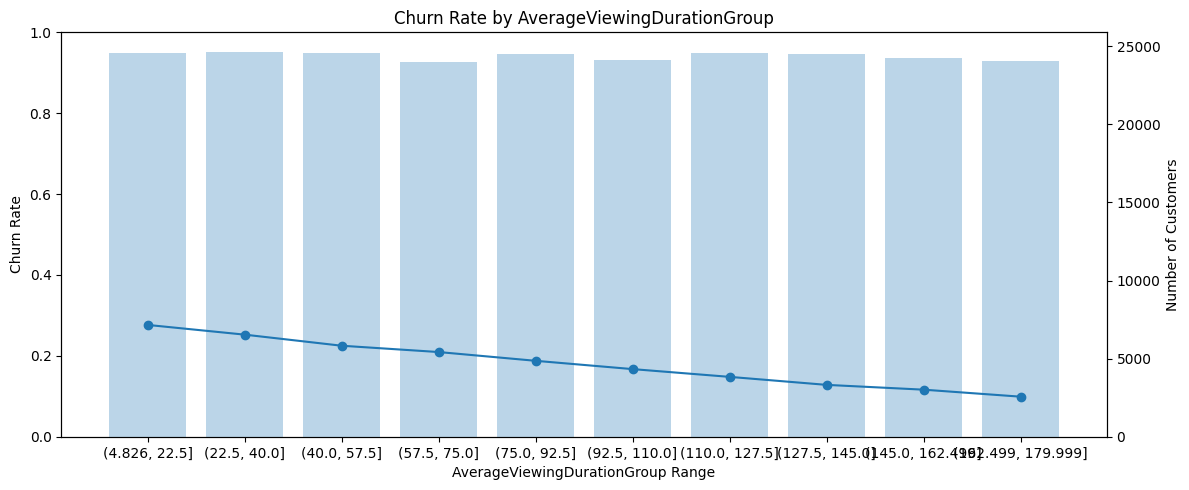

In [15]:
import matplotlib.pyplot as plt

avg_view_duration_dist = (
    df.assign(
        AverageViewingDurationGroup=pd.cut(
            df["AverageViewingDuration"],
            bins=10
        )
    )
    .groupby("AverageViewingDurationGroup", observed=True)
    .agg(
        churn_rate=("Churn", "mean"),
        customer_count=("Churn", "size")
    )
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    avg_view_duration_dist["AverageViewingDurationGroup"].astype(str),
    avg_view_duration_dist["churn_rate"],
    marker="o"
)

ax1.set_xlabel("AverageViewingDurationGroup Range")
ax1.set_ylabel("Churn Rate")
ax1.set_ylim(0,1)

ax2 = ax1.twinx()

ax2.bar(
    avg_view_duration_dist["AverageViewingDurationGroup"].astype(str),
    avg_view_duration_dist["customer_count"],
    alpha=0.3
)

ax2.set_ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.title("Churn Rate by AverageViewingDurationGroup")
plt.tight_layout()

plt.show()

In [ ]:
df[["AverageViewingDuration", "Churn"]].corr()

,AverageViewingDuration,Churn
AverageViewingDuration,1.000000,-0.146897
Churn,-0.146897,1.000000


---

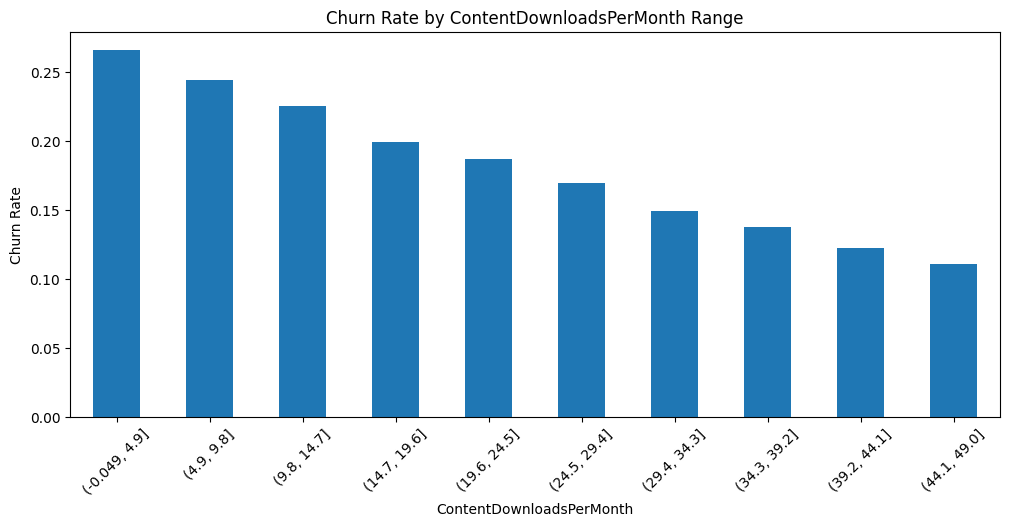

In [ ]:
df["ContentDownloadsPerMonthGroup"] = pd.cut(
    df["ContentDownloadsPerMonth"],
    bins=10
)

monthly_churn = (
    df.groupby("ContentDownloadsPerMonthGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("ContentDownloadsPerMonth")
plt.title("Churn Rate by ContentDownloadsPerMonth Range")

plt.xticks(rotation=45)
plt.show()



In [ ]:
df[["ContentDownloadsPerMonth", "Churn"]].corr()

,ContentDownloadsPerMonth,Churn
ContentDownloadsPerMonth,1.000000,-0.129752
Churn,-0.129752,1.000000


---

GenrePreference
Comedy     0.193416
Sci-Fi     0.191444
Drama      0.178709
Fantasy    0.176734
Action     0.165866
Name: Churn, dtype: float64


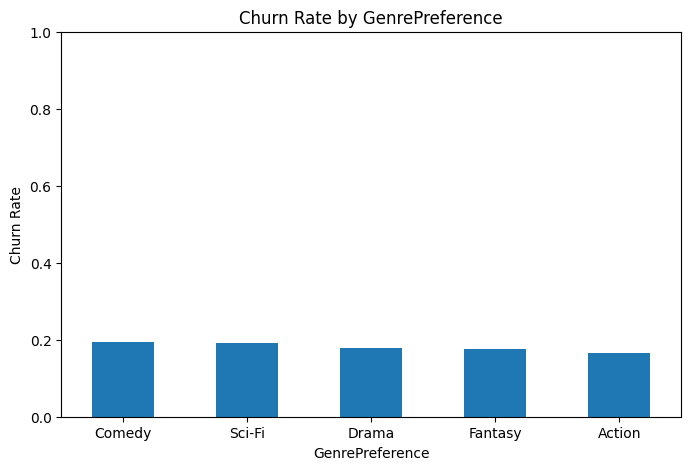

In [ ]:
genrepreferences_churn = (
    df.groupby("GenrePreference")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(genrepreferences_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

genrepreferences_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("GenrePreference")
plt.title("Churn Rate by GenrePreference")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()



---

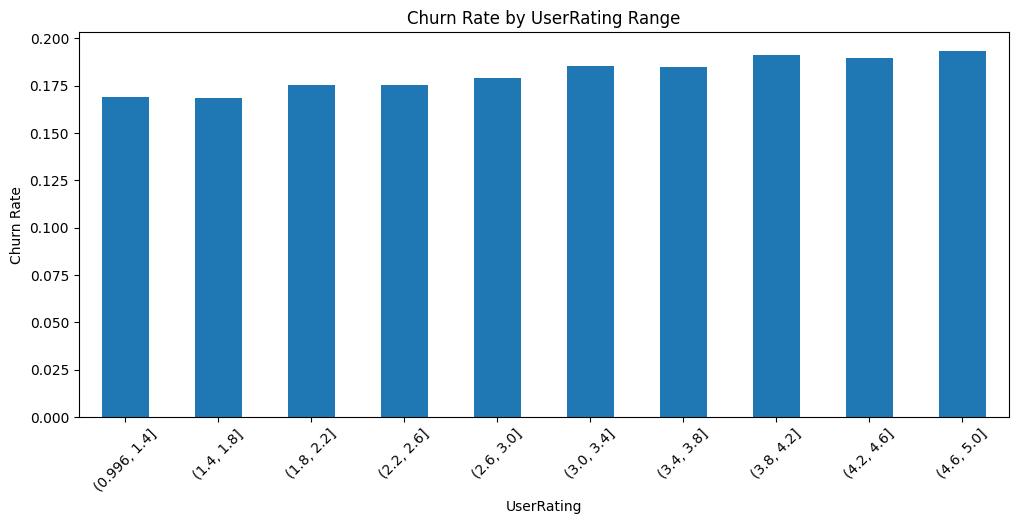

In [ ]:
df["UserRatingGroup"] = pd.cut(
    df["UserRating"],
    bins=10
)

monthly_churn = (
    df.groupby("UserRatingGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("UserRating")
plt.title("Churn Rate by UserRating Range")

plt.xticks(rotation=45)
plt.show()



In [ ]:
df[["UserRating", "Churn"]].corr()

,UserRating,Churn
UserRating,1.000000,0.022124
Churn,0.022124,1.000000


---

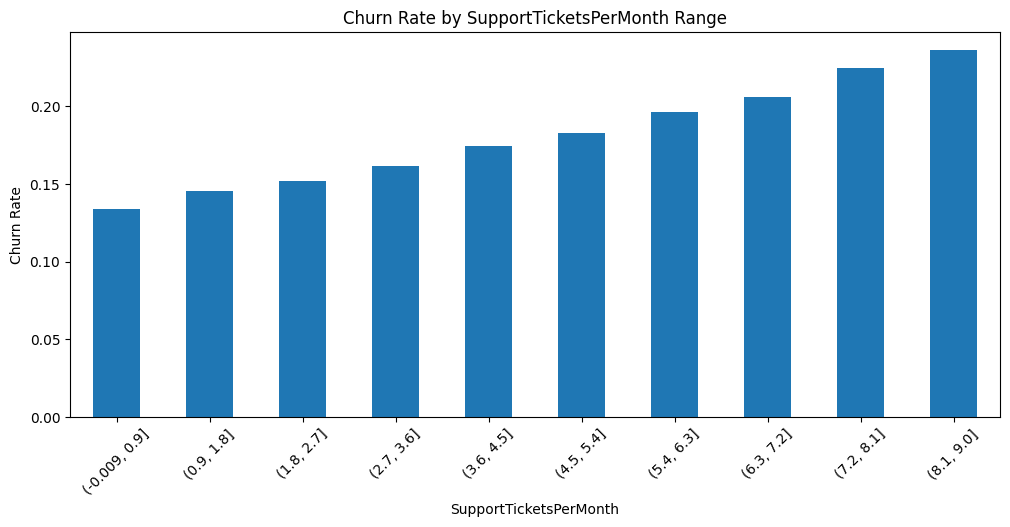

                        SupportTicketsPerMonth     Churn
SupportTicketsPerMonth                1.000000  0.084064
Churn                                 0.084064  1.000000


In [ ]:
df["SupportTicketsPerMonthGroup"] = pd.cut(
    df["SupportTicketsPerMonth"],
    bins=10
)

monthly_churn = (
    df.groupby("SupportTicketsPerMonthGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("SupportTicketsPerMonth")
plt.title("Churn Rate by SupportTicketsPerMonth Range")

plt.xticks(rotation=45)
plt.show()

print(df[["SupportTicketsPerMonth", "Churn"]].corr())



---

Gender
Male      0.184109
Female    0.178356
Name: Churn, dtype: float64


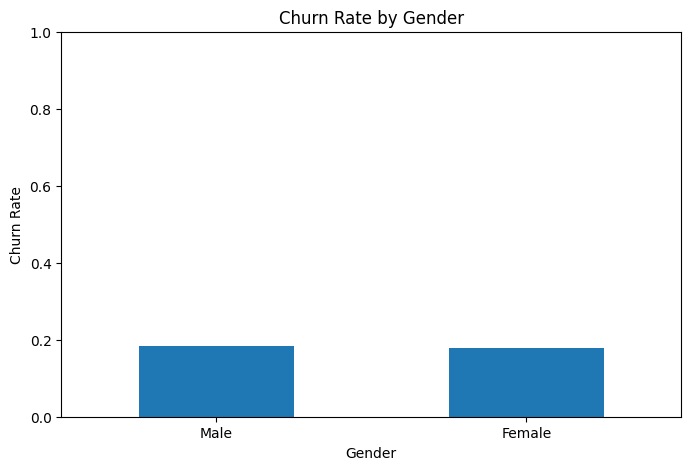

In [ ]:
gender_churn = (
    df.groupby("Gender")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(gender_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

gender_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("Gender")
plt.title("Churn Rate by Gender")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()



---

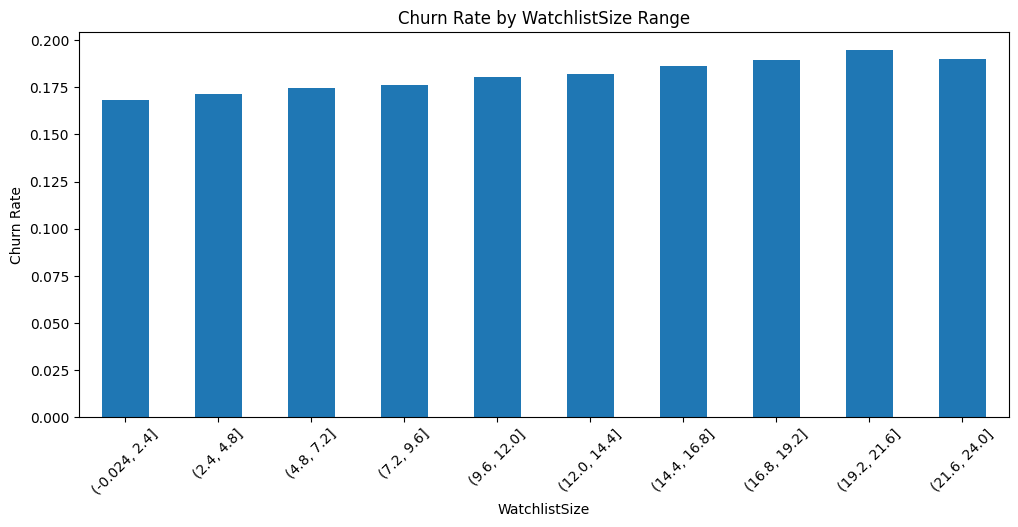

               WatchlistSize     Churn
WatchlistSize       1.000000  0.021739
Churn               0.021739  1.000000


In [ ]:
df["WatchlistSizeGroup"] = pd.cut(
    df["WatchlistSize"],
    bins=10
)

monthly_churn = (
    df.groupby("WatchlistSizeGroup", observed=True)["Churn"]
      .mean()
)

monthly_churn.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Churn Rate")
plt.xlabel("WatchlistSize")
plt.title("Churn Rate by WatchlistSize Range")

plt.xticks(rotation=45)
plt.show()

print(df[["WatchlistSize", "Churn"]].corr())



---


ParentalControl
No     0.183366
Yes    0.179105
Name: Churn, dtype: float64


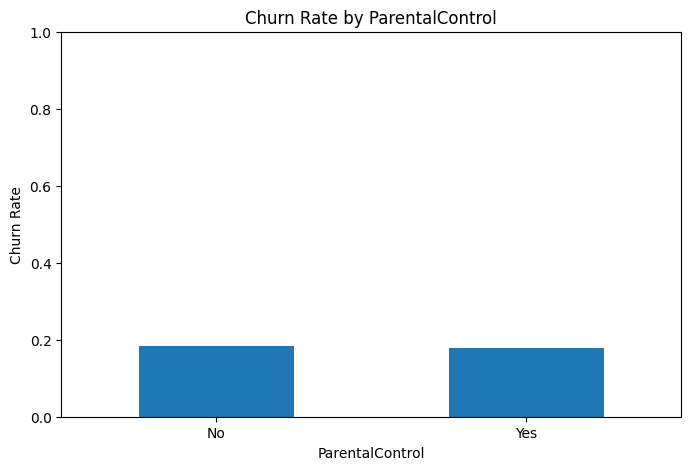

In [ ]:
parentalcontrol_churn = (
    df.groupby("ParentalControl")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(parentalcontrol_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

parentalcontrol_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("ParentalControl")
plt.title("Churn Rate by ParentalControl")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()



---

SubtitlesEnabled
No     0.186009
Yes    0.176477
Name: Churn, dtype: float64


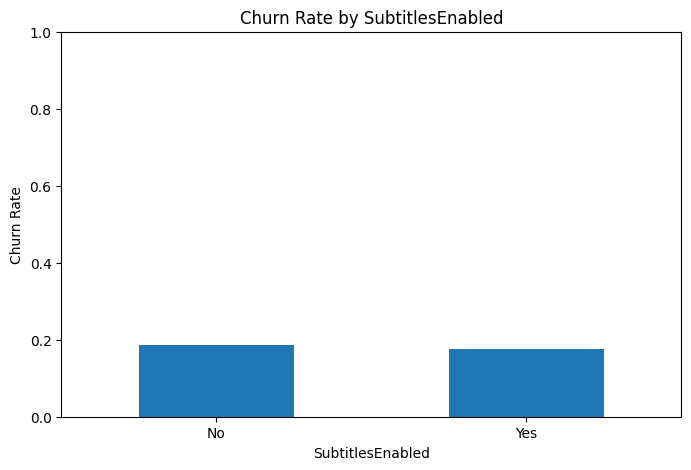

In [ ]:
subtitles_churn = (
    df.groupby("SubtitlesEnabled")["Churn"]
      .mean()
      .sort_values(ascending=False)
)

print(subtitles_churn)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

subtitles_churn.plot(
    kind="bar"
)

plt.ylabel("Churn Rate")
plt.xlabel("SubtitlesEnabled")
plt.title("Churn Rate by SubtitlesEnabled")

plt.ylim(0,1)
plt.xticks(rotation=0)

plt.show()


---

# Features vs. Target Relationships Notes
...

---

# Features vs Features